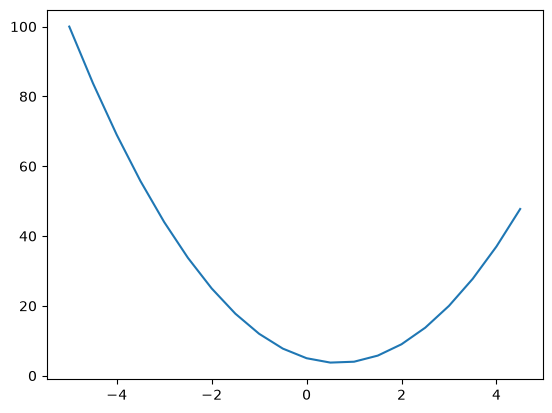

In [9]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
def f(x):
    return 3*x**2 -4*x + 5
f(9.0)
xs = np.arange(-5, 5, 0.5)
ys = f(xs)
plt.plot(xs,ys)



In [10]:
h = 0.00001
x = 2/3
(f(x+h) - f(x))/h

3.0000002482211127e-05

In [11]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [12]:
h = 0.0001
#inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c+= h
d2 = a*b + c
print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [43]:
class Value:
    def __init__(self, data, _children=(), _op = '', label = ''):
        self.data = data #data
        self._prev = set(_children) # the use of children is to see the result comes from which elements
        self._op = _op #operation
        self.label = label #label like 'a', 'b' and so on
        self.grad = 0.0 # the value for gradient
        self._backward = lambda: None
    def __repr__(self):
        return f"Value(data = {self.data})"
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out =  Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0* out.grad
        out._backward = _backward
        return out
    def __truediv__(self, other):
        return self * other**-1
    def __rmul__(self, other):
        return self * other
    def __neg__(self):
        return self * -1
    def __sub__(self, other):        
        other = other if isinstance(other, Value) else Value(other)
        return self+ (-other)
    def __radd__(self, other):
        return self + other
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    def __pow__(self, other):
        assert isinstance(other, (int, float)), " only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1))*out.grad
        out._backward = _backward
        return out
  

'''
a = Value(2.0, label = 'a')
b = Value(5.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e' # value - 10.0
d = e + c; d.label = 'd' # value - 10+10 = 20.0
f = Value(2.0, label = 'f') # value - 2.0
L = d*f; L.label = 'L' # value - 40.0
'''
a= Value(2.0)
a-5


Value(data = -3.0)

In [16]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges
def draw_dot(root):
    dot = Digraph(format = 'svg', graph_attr= {'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{%s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape= 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import math

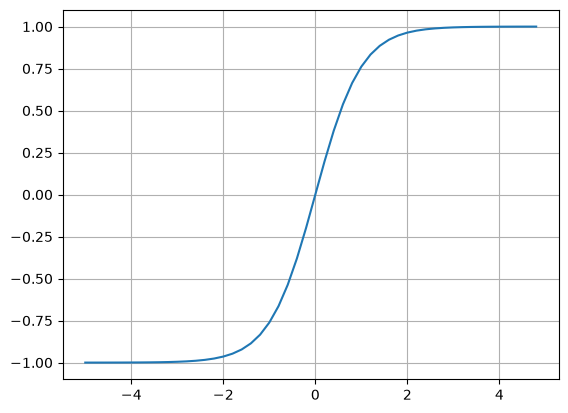

In [18]:
plt.plot(np.arange(-5,5, 0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid(); 

In [20]:
import math
#inputs x1, x2
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0, label = 'x2')
#weights w1,w2
w1 = Value(-3.0, label = 'w1')
w2 = Value(1.0, label = 'w2')
#bias of the neuron
b = Value(6.8813735870195432, label = 'b')
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


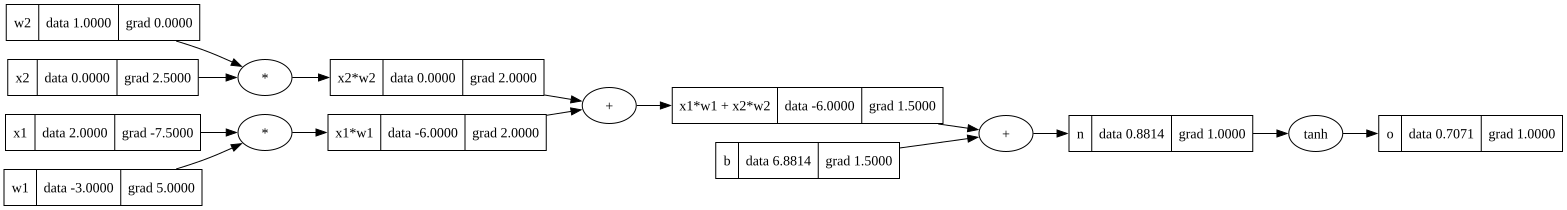

In [24]:
draw_dot(o)

In [23]:
o.backward()

In [25]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
build_topo(o)
topo    


[Value(data = 2.0),
 Value(data = -3.0),
 Value(data = -6.0),
 Value(data = 1.0),
 Value(data = 0.0),
 Value(data = 0.0),
 Value(data = -6.0),
 Value(data = 6.881373587019543),
 Value(data = 0.8813735870195432),
 Value(data = 0.7071067811865476)]

In [26]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
b._backward()

In [ ]:
'''# For plus '+' sign the gradient is same in all of the child nodes
# Like for example, the gradient of n is 0.5 and its children nodes
# are x1w1x2w2 and b which makes the gradient of these two child nodes same as that
# of parent node that is n
# Now for multiply '*' sign, the gradient of a particular child is the product of
# the data of the other sign and the gradient of the parent node
x1w1x2w2.grad = 0.5 
x2w2.grad = 0.5
x1w1.grad = 0.5
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
b.grad = 0.5
n.grad = 0.5
o.grad = 1.0
'''

In [27]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio


In [29]:
import torch


In [30]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [32]:
#Going to start neural network implementation
import random
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)

Value(data = -0.7773841239520757)

In [44]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, -1.0] # desired targets
for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred))
    #backward pass
    for p in n.parameters():
        p.grad = 0.0
    loss.backward()
    #update
    for p in n.parameters():
        p.data += -0.1 * p.grad
    print(k, loss.data)

0 5.365901109425221
1 3.2989154479559506
2 2.8361680491021906
3 2.467428921204066
4 2.0186077867838983
5 1.1002655647578212
6 0.8539402525872828
7 2.140250437181786
8 3.5403229131148164
9 0.8272654867538383
10 0.7093967235521501
11 2.2748403853761285
12 4.847084376746816
13 1.153375101808316
14 0.6916189028934052
15 0.34725251864128015
16 0.19318910924825722
17 0.12828875181198082
18 0.09534261827504312
19 0.07590573391931767
